<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_07/Linear_regression_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 2: Linear Regression
## Predicting House Price with Multiple Features

**What this notebook does:**

1. Builds a synthetic house-price dataset with both numeric (`sqft`, `bedrooms`, `age`) and categorical (`neighborhood`) features.
2. Sets up the **train/test split** from Lesson 1.
3. Builds the **`Pipeline + ColumnTransformer`** pattern we'll use for every model in this class.
4. Fits a `LinearRegression`, evaluates it on the test set with **MAE and RMSE**, and inspects the coefficient for each feature (including each one-hot category).

Companion notes: `lesson2_linear_regression.pdf`.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#sklearn - basic machine learning in python
from sklearn.model_selection import train_test_split #split our data for us
from sklearn.compose import ColumnTransformer #help us with onehot encoding
from sklearn.preprocessing import OneHotEncoder #ovy
from sklearn.linear_model import LinearRegression #our model
from sklearn.pipeline import Pipeline #our model becomes more than regression - workflow
from sklearn.metrics import mean_absolute_error, root_mean_squared_error #metrics



In [4]:
homes=pd.read_csv('homes.csv')
homes.head()

,sqft,bedrooms,age,neighborhood,price_k
0,2520,5,46,Downtown,657.9
1,1528,2,71,Rural,308.4
2,911,4,51,Downtown,317.3
3,845,1,46,Downtown,272.3
4,2996,2,39,Suburb,615.0


## 2. Train/test split

Same recipe as Lesson 1. We split **before** doing any preprocessing.

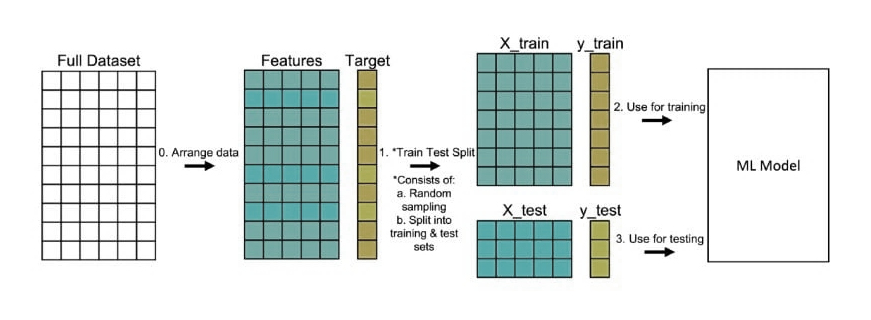

In [10]:
#Split the features from the target
X =homes[['sqft','bedrooms','age','neighborhood']]#features
y =homes['price_k']
#Split the data into test and train
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)



In [14]:
X_test.shape

(50, 4)

## 3. The Pipeline + ColumnTransformer pattern

We treat numeric columns one way (pass through) and categorical columns another (one-hot encode), then hand the whole package to `LinearRegression`.

- **`OneHotEncoder`
- **`handle_unknown='ignore'`** keeps the encoder from crashing if a test home is in a neighborhood that didn't appear in training.
- The **`Pipeline`** glues preprocessing and the model into a single object.

In [15]:
#identify numeric columns which will not require any transformation
numeric_cols     =['sqft','bedrooms','age']
#identify categorical columns that will require one hot encoding
categorical_cols =['neighborhood']
#create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(handle_unknown='ignore'),
        categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ]
)



In [16]:
#Build and see the model - the model has two parts, the preprocessor and
#the regression
model=Pipeline([
    ('prep',preprocessor),
    ('lr',LinearRegression())
])

model


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighborhood']),
                                                 ('num', 'passthrough',
                                                  ['sqft', 'bedrooms',
                                                   'age'])])),
                ('lr', LinearRegression())])

## 4. Fit on training, predict on test

In [17]:
#Execute the model - find the best fit line
model.fit(X_train,y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighborhood']),
                                                 ('num', 'passthrough',
                                                  ['sqft', 'bedrooms',
                                                   'age'])])),
                ('lr', LinearRegression())])

In [22]:
#Assess the model using the test data
y_pred=model.predict(X_test)
preview=pd.DataFrame({'Actual':y_test,'Predict':y_pred})
preview


,Actual,Predict
95,797.8,788.322721
15,266.9,253.917466
30,564.3,570.887729
158,720.0,704.305729
128,386.2,346.596186
115,385.9,415.046667
69,278.9,253.372058
170,468.6,416.465050
174,736.0,728.839105
45,627.4,601.414379


## 5. Score the model

**Mean Absolute Error (MAE)**

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$$

**Root Mean Squared Error (RMSE)**

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}$$

We compute **MAE** ("average dollar miss") and **RMSE** (penalizes big misses more) on both training and test sets. Bigger train–test gap = more overfitting.

In [23]:
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
print(f':MAE=${mae*1000} and RMSE=${rmse}')



:MAE=$24428.005735849412 and RMSE=$30.80854460970991


Read this as: *on average, our model is off by about \$X per home on data it has never seen*.

Training and test errors are close, which is what we expect for a linear model that's well-matched to a linear data-generating process.

## 6. Inspect the coefficients

Each feature gets a coefficient. For one-hot encoded categories, **each category** gets its own coefficient (except the baseline category, which was dropped).

In [24]:
# Pull feature names out of the preprocessor and pair them with coefficients
feature_names = model.named_steps['prep'].get_feature_names_out()
coefs = model.named_steps['lr'].coef_
intercept = model.named_steps['lr'].intercept_

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient_$K': coefs.round(2),
})
print(f'intercept = ${intercept*1000:,.0f}')
coef_table

intercept = $72,757


,feature,coefficient_$K
0,cat__neighborhood_Downtown,29.76
1,cat__neighborhood_Rural,-33.47
2,cat__neighborhood_Suburb,3.71
3,num__sqft,0.18
4,num__bedrooms,25.00
5,num__age,-0.65


Using all four features cuts the average dollar miss substantially. Each feature is carrying information the others don't.